# 07 Robustness Variants

This notebook is a targeted follow-up to Notebook 4. It does **not** rerun the full model comparison. Instead, it checks a few robustness questions that came up after the main modeling run:

1. Can a kernel SVM add useful nonlinear signal?
2. Do early-stopped boosting variants perform competitively?
3. Do more-regularized/pruned boosting variants reduce overfitting while preserving AMEX-M?

The notebook reads only the engineered customer-level feature table from the 1M-row preprocessing output.

## Runtime controls

The exact RBF SVM is intentionally sampled because a full kernel SVM is not memory-safe for the full engineered training table. XGBoost and LightGBM variants use a train/validation split rather than full cross-validation so this notebook can run much faster than Notebook 4.

In [1]:
from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/mplconfig')
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics import roc_auc_score, average_precision_score

import lightgbm as lgb
import xgboost as xgb
import joblib

INTERIM = Path('../data/interim')
REPORTS = Path('../reports/modeling')
MODEL_DIR = Path('../models/supervised')
REPORTS.mkdir(parents=True, exist_ok=True)

SEED = 5241
PARALLEL_JOBS = 2

# Exact kernel SVM is quadratic-ish in sample size. Increase only if you have time.
RUN_EXACT_RBF_SVM = True
RBF_SVM_SAMPLE_N = 8_000

# Nystroem approximates an RBF kernel with explicit features, making a larger nonlinear SVM feasible.
RUN_NYSTROEM_SVM = True
NYSTROEM_SAMPLE_N = 25_000
NYSTROEM_COMPONENTS = 800

RUN_BOOSTING_VARIANTS = True
VALIDATION_SIZE = 0.20

FEATURES_PATH = INTERIM / 'train_features.parquet'
HOLDOUT_PATH = INTERIM / 'test_features_holdout.parquet'
assert FEATURES_PATH.exists(), 'Run notebooks/03_feature_engineering.ipynb first.'

print(f'PARALLEL_JOBS={PARALLEL_JOBS}')
print(f'RUN_EXACT_RBF_SVM={RUN_EXACT_RBF_SVM}, RBF_SVM_SAMPLE_N={RBF_SVM_SAMPLE_N:,}')
print(f'RUN_NYSTROEM_SVM={RUN_NYSTROEM_SVM}, NYSTROEM_SAMPLE_N={NYSTROEM_SAMPLE_N:,}, components={NYSTROEM_COMPONENTS:,}')

PARALLEL_JOBS=2
RUN_EXACT_RBF_SVM=True, RBF_SVM_SAMPLE_N=8,000
RUN_NYSTROEM_SVM=True, NYSTROEM_SAMPLE_N=25,000, components=800


## Load data and recreate the Notebook 4 split

We use the same `SEED = 5241` and 80/20 stratified split as Notebook 4. If the disjoint feature-level holdout exists, we evaluate there too.

In [2]:
features = pd.read_parquet(FEATURES_PATH)
y = features['target'].astype(int)
X = features.drop(columns='target')

X_train, X_internal, y_train, y_internal = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

if HOLDOUT_PATH.exists():
    holdout = pd.read_parquet(HOLDOUT_PATH)
    X_holdout = holdout.drop(columns='target')
    y_holdout = holdout['target'].astype(int)
    if list(X_holdout.columns) != list(X.columns):
        print('Holdout schema does not match train features; holdout evaluation will be skipped.')
        X_holdout = y_holdout = None
else:
    X_holdout = y_holdout = None

print(f'train: {X_train.shape}, internal test: {X_internal.shape}')
if X_holdout is not None:
    print(f'disjoint holdout: {X_holdout.shape}')
print(f'target rates: train={y_train.mean():.3f}, internal={y_internal.mean():.3f}' + (f', holdout={y_holdout.mean():.3f}' if X_holdout is not None else ''))

train: (66496, 968), internal test: (16625, 968)
disjoint holdout: (83053, 968)
target rates: train=0.270, internal=0.270, holdout=0.268


## Metrics

AMEX-M is the project metric. ROC-AUC and PR-AUC are secondary ranking metrics.

In [3]:
def amex_metric(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    labels = np.transpose(np.array([y_true, y_pred]))
    labels = labels[labels[:, 1].argsort()[::-1]]
    weights = np.where(labels[:, 0] == 0, 20, 1)
    cutoff = labels[np.cumsum(weights) <= int(0.04 * np.sum(weights))]
    top_four = cutoff[:, 0].sum() / labels[:, 0].sum()

    gini = [0.0, 0.0]
    for i in [1, 0]:
        labels = np.transpose(np.array([y_true, y_pred]))
        labels = labels[labels[:, i].argsort()[::-1]]
        weights = np.where(labels[:, 0] == 0, 20, 1)
        random = np.cumsum(weights / weights.sum())
        lorentz = np.cumsum(labels[:, 0] * weights) / np.sum(labels[:, 0] * weights)
        gini[i] = np.sum((lorentz - random) * weights)
    return 0.5 * (gini[1] / gini[0] + top_four), gini[1] / gini[0], top_four

def model_scores(model, X_eval):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X_eval)
    return model.predict(X_eval)

def evaluate_scores(model_name, variant, split, y_true, scores, fit_seconds=None, train_rows=None, notes=''):
    M, G, D = amex_metric(y_true, scores)
    return {
        'model': model_name,
        'variant': variant,
        'split': split,
        'amex_M': M,
        'gini_G': G,
        'capture_D@4pct': D,
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
        'fit_seconds': fit_seconds,
        'train_rows': train_rows,
        'notes': notes,
    }

results = []

## Existing Notebook 4 final model baseline

This gives the robustness variants a reference point without refitting Notebook 4.

In [4]:
if (MODEL_DIR / 'final_model.joblib').exists():
    final_model = joblib.load(MODEL_DIR / 'final_model.joblib')
    for split_name, Xe, ye in [('internal', X_internal, y_internal), ('holdout', X_holdout, y_holdout)]:
        if Xe is None:
            continue
        scores = model_scores(final_model, Xe)
        results.append(evaluate_scores('final_model', 'notebook_4_artifact', split_name, ye, scores, train_rows=len(X_train), notes='Saved model from Notebook 4'))
    display(pd.DataFrame(results).round(4))
else:
    print('No final_model.joblib found; skipping saved baseline.')

,model,variant,split,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,fit_seconds,train_rows,notes
0,final_model,notebook_4_artifact,internal,0.7716,0.9102,0.6330,0.9551,0.8908,None,66496,Saved model from Notebook 4
1,final_model,notebook_4_artifact,holdout,0.7826,0.9190,0.6462,0.9595,0.8970,None,66496,Saved model from Notebook 4


## Sampled exact RBF-kernel SVM

This is the direct kernel SVM check. It uses only a stratified sample because exact RBF SVM can become very slow and memory-heavy on tens of thousands of customers.

In [5]:
import time

if RUN_EXACT_RBF_SVM:
    n = min(RBF_SVM_SAMPLE_N, len(X_train))
    X_rbf, _, y_rbf, _ = train_test_split(X_train, y_train, train_size=n, stratify=y_train, random_state=SEED)
    rbf_svm = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', SVC(kernel='rbf', C=1.0, gamma='scale', probability=False, cache_size=2000, random_state=SEED)),
    ])
    t0 = time.time()
    rbf_svm.fit(X_rbf, y_rbf)
    fit_seconds = time.time() - t0
    print(f'exact RBF SVM fit finished in {fit_seconds:.1f}s on {len(X_rbf):,} rows')
    for split_name, Xe, ye in [('internal', X_internal, y_internal), ('holdout', X_holdout, y_holdout)]:
        if Xe is None:
            continue
        scores = model_scores(rbf_svm, Xe)
        results.append(evaluate_scores('kernel_svm', 'exact_rbf_sample', split_name, ye, scores, fit_seconds, len(X_rbf), 'Exact RBF SVC on stratified sample'))
else:
    print('Skipping exact RBF SVM.')

pd.DataFrame(results).sort_values(['split', 'amex_M'], ascending=[True, False]).round(4)

exact RBF SVM fit finished in 6.0s on 8,000 rows


,model,variant,split,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,fit_seconds,train_rows,notes
1,final_model,notebook_4_artifact,holdout,0.7826,0.9190,0.6462,0.9595,0.8970,NaN,66496,Saved model from Notebook 4
3,kernel_svm,exact_rbf_sample,holdout,0.7430,0.8992,0.5868,0.9496,0.8645,6.0415,8000,Exact RBF SVC on stratified sample
0,final_model,notebook_4_artifact,internal,0.7716,0.9102,0.6330,0.9551,0.8908,NaN,66496,Saved model from Notebook 4
2,kernel_svm,exact_rbf_sample,internal,0.7398,0.8929,0.5868,0.9464,0.8680,6.0415,8000,Exact RBF SVC on stratified sample


## Early-stopped and more-regularized boosting variants

These variants use one validation split inside the training data. They are not a replacement for full CV, but they directly test the regularization/early-stopping concern without rerunning Notebook 4 for four hours.

In [7]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_train, y_train, test_size=VALIDATION_SIZE, stratify=y_train, random_state=SEED
)
print(f'boosting fit: {X_fit.shape}, validation: {X_valid.shape}')

def fit_eval_variant(model_name, variant, model, fit_kwargs=None, notes=''):
    fit_kwargs = fit_kwargs or {}
    t0 = time.time()
    model.fit(X_fit, y_fit, **fit_kwargs)
    fit_seconds = time.time() - t0
    rows = []
    for split_name, Xe, ye in [('valid', X_valid, y_valid), ('internal', X_internal, y_internal), ('holdout', X_holdout, y_holdout)]:
        if Xe is None:
            continue
        scores = model_scores(model, Xe)
        rows.append(evaluate_scores(model_name, variant, split_name, ye, scores, fit_seconds, len(X_fit), notes))
    return rows, model

boosting_models = []

if RUN_BOOSTING_VARIANTS:
    lgb_early = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=63,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        n_jobs=PARALLEL_JOBS,
        verbose=-1,
        random_state=SEED,
    )
    rows, fitted = fit_eval_variant(
        'lightgbm',
        'early_stopped_regularized',
        lgb_early,
        fit_kwargs={
            'eval_set': [(X_valid, y_valid)],
            'eval_metric': 'auc',
            'callbacks': [lgb.early_stopping(75, verbose=False)],
        },
        notes='Early stopping plus shrinkage/subsample/regularization',
    )
    results.extend(rows)
    boosting_models.append(('lightgbm_early_stopped_regularized', fitted))
    print('LightGBM best_iteration_:', getattr(fitted, 'best_iteration_', None))

    lgb_pruned = lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=4,
        min_child_samples=250,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=1.0,
        reg_lambda=10.0,
        n_jobs=PARALLEL_JOBS,
        verbose=-1,
        random_state=SEED,
    )
    rows, fitted = fit_eval_variant(
        'lightgbm',
        'strongly_regularized_pruned',
        lgb_pruned,
        fit_kwargs={
            'eval_set': [(X_valid, y_valid)],
            'eval_metric': 'auc',
            'callbacks': [lgb.early_stopping(75, verbose=False)],
        },
        notes='Smaller leaves/depth, larger min_child_samples, L1/L2 regularization',
    )
    results.extend(rows)
    boosting_models.append(('lightgbm_strongly_regularized_pruned', fitted))
    print('Pruned LightGBM best_iteration_:', getattr(fitted, 'best_iteration_', None))

    xgb_early = xgb.XGBClassifier(
        n_estimators=3000,
        learning_rate=0.02,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=8.0,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_jobs=PARALLEL_JOBS,
        random_state=SEED,
        early_stopping_rounds=75,
    )
    rows, fitted = fit_eval_variant(
        'xgboost',
        'early_stopped_regularized',
        xgb_early,
        fit_kwargs={'eval_set': [(X_valid, y_valid)], 'verbose': False},
        notes='Early stopping plus max_depth/min_child_weight/subsample/regularization',
    )
    results.extend(rows)
    boosting_models.append(('xgboost_early_stopped_regularized', fitted))
    print('XGBoost best_iteration:', getattr(fitted, 'best_iteration', None))

    xgb_pruned = xgb.XGBClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=25,
        gamma=1.0,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=1.0,
        reg_lambda=12.0,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        n_jobs=PARALLEL_JOBS,
        random_state=SEED,
        early_stopping_rounds=75,
    )
    rows, fitted = fit_eval_variant(
        'xgboost',
        'strongly_regularized_pruned',
        xgb_pruned,
        fit_kwargs={'eval_set': [(X_valid, y_valid)], 'verbose': False},
        notes='Shallow trees, high min_child_weight, gamma, L1/L2 regularization',
    )
    results.extend(rows)
    boosting_models.append(('xgboost_strongly_regularized_pruned', fitted))
    print('Pruned XGBoost best_iteration:', getattr(fitted, 'best_iteration', None))
else:
    print('Skipping boosting variants.')

pd.DataFrame(results).sort_values(['split', 'amex_M'], ascending=[True, False]).round(4)

boosting fit: (53196, 968), validation: (13300, 968)
LightGBM best_iteration_: 545
Pruned LightGBM best_iteration_: 695
XGBoost best_iteration: 1356
Pruned XGBoost best_iteration: 1042


,model,variant,split,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,fit_seconds,train_rows,notes
1,final_model,notebook_4_artifact,holdout,0.7826,0.9190,0.6462,0.9595,0.8970,NaN,66496,Saved model from Notebook 4
17,xgboost,strongly_regularized_pruned,holdout,0.7823,0.9186,0.6460,0.9593,0.8962,90.5597,53196,"Shallow trees, high min_child_weight, gamma, L..."
14,xgboost,early_stopped_regularized,holdout,0.7806,0.9188,0.6424,0.9594,0.8964,130.2489,53196,Early stopping plus max_depth/min_child_weight...
8,lightgbm,early_stopped_regularized,holdout,0.7803,0.9187,0.6419,0.9594,0.8970,56.3551,53196,Early stopping plus shrinkage/subsample/regula...
11,lightgbm,strongly_regularized_pruned,holdout,0.7787,0.9180,0.6394,0.9590,0.8956,22.7757,53196,"Smaller leaves/depth, larger min_child_samples..."
3,kernel_svm,exact_rbf_sample,holdout,0.7430,0.8992,0.5868,0.9496,0.8645,6.0415,8000,Exact RBF SVC on stratified sample
5,kernel_svm,nystroem_rbf_linear_svc,holdout,0.5990,0.7680,0.4301,0.8840,0.7244,2.7497,25000,Approximate RBF kernel via Nystroem
0,final_model,notebook_4_artifact,internal,0.7716,0.9102,0.6330,0.9551,0.8908,NaN,66496,Saved model from Notebook 4
13,xgboost,early_stopped_regularized,internal,0.7691,0.9106,0.6276,0.9553,0.8901,130.2489,53196,Early stopping plus max_depth/min_child_weight...
7,lightgbm,early_stopped_regularized,internal,0.7674,0.9102,0.6247,0.9551,0.8896,56.3551,53196,Early stopping plus shrinkage/subsample/regula...


## Summary tables and plots

,model,variant,split,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,fit_seconds,train_rows,notes
0,final_model,notebook_4_artifact,holdout,0.7826,0.9190,0.6462,0.9595,0.8970,NaN,66496,Saved model from Notebook 4
1,xgboost,strongly_regularized_pruned,holdout,0.7823,0.9186,0.6460,0.9593,0.8962,90.5597,53196,"Shallow trees, high min_child_weight, gamma, L..."
2,xgboost,early_stopped_regularized,holdout,0.7806,0.9188,0.6424,0.9594,0.8964,130.2489,53196,Early stopping plus max_depth/min_child_weight...
3,lightgbm,early_stopped_regularized,holdout,0.7803,0.9187,0.6419,0.9594,0.8970,56.3551,53196,Early stopping plus shrinkage/subsample/regula...
4,lightgbm,strongly_regularized_pruned,holdout,0.7787,0.9180,0.6394,0.9590,0.8956,22.7757,53196,"Smaller leaves/depth, larger min_child_samples..."
5,kernel_svm,exact_rbf_sample,holdout,0.7430,0.8992,0.5868,0.9496,0.8645,6.0415,8000,Exact RBF SVC on stratified sample
6,kernel_svm,nystroem_rbf_linear_svc,holdout,0.5990,0.7680,0.4301,0.8840,0.7244,2.7497,25000,Approximate RBF kernel via Nystroem
7,final_model,notebook_4_artifact,internal,0.7716,0.9102,0.6330,0.9551,0.8908,NaN,66496,Saved model from Notebook 4
8,xgboost,early_stopped_regularized,internal,0.7691,0.9106,0.6276,0.9553,0.8901,130.2489,53196,Early stopping plus max_depth/min_child_weight...
9,lightgbm,early_stopped_regularized,internal,0.7674,0.9102,0.6247,0.9551,0.8896,56.3551,53196,Early stopping plus shrinkage/subsample/regula...


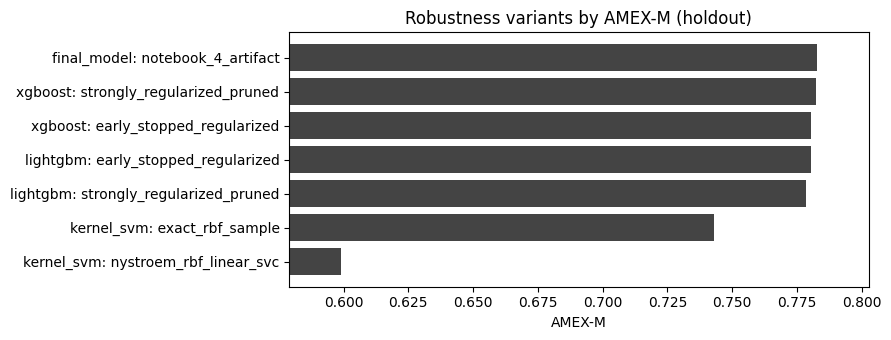

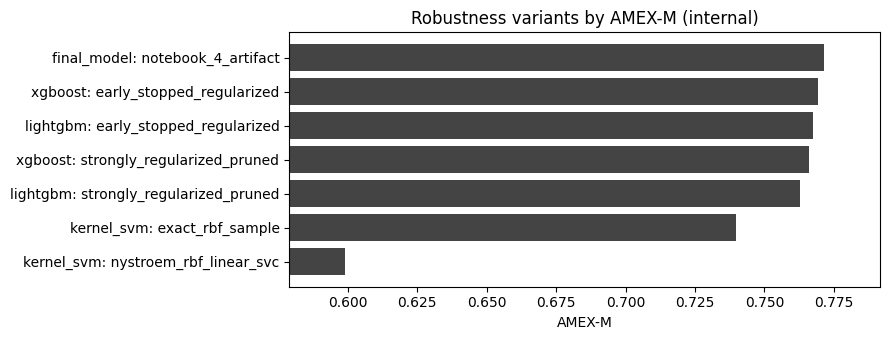

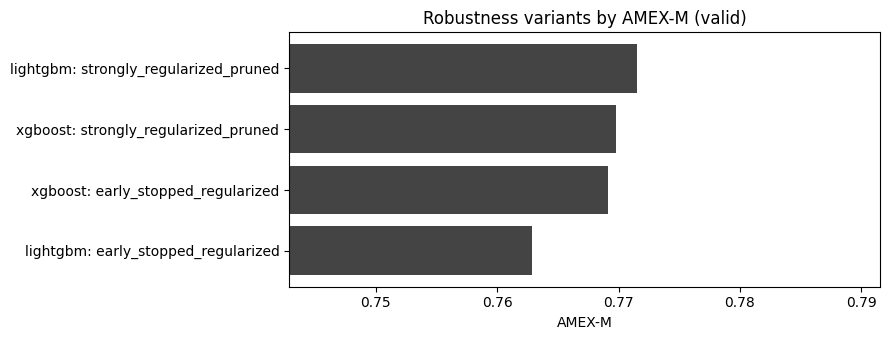

saved ../reports/modeling/robustness_variants.csv


In [8]:
robustness = pd.DataFrame(results)
robustness = robustness.sort_values(['split', 'amex_M'], ascending=[True, False]).reset_index(drop=True)
robustness.to_csv(REPORTS / 'robustness_variants.csv', index=False)
display(robustness.round(4))

for split in robustness['split'].unique():
    plot_df = robustness[robustness['split'] == split].copy()
    plot_df['label'] = plot_df['model'] + ': ' + plot_df['variant']
    plot_df = plot_df.sort_values('amex_M')
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(plot_df))))
    ax.barh(plot_df['label'], plot_df['amex_M'], color='#444444')
    ax.set_title(f'Robustness variants by AMEX-M ({split})')
    ax.set_xlabel('AMEX-M')
    ax.set_xlim(max(0, plot_df['amex_M'].min() - 0.02), min(1.0, plot_df['amex_M'].max() + 0.02))
    fig.tight_layout()
    fig.savefig(REPORTS / f'robustness_variants_{split}.png', dpi=160)
    plt.show()

print(f"saved {REPORTS / 'robustness_variants.csv'}")

In [9]:
if not robustness.empty:
    for split in ['holdout', 'internal', 'valid']:
        if split not in set(robustness['split']):
            continue
        best = robustness[robustness['split'] == split].sort_values('amex_M', ascending=False).iloc[0]
        print(f"Best {split}: {best['model']} / {best['variant']} with AMEX-M={best['amex_M']:.4f}, ROC-AUC={best['roc_auc']:.4f}")

    kernel_rows = robustness[robustness['model'].eq('kernel_svm')]
    if not kernel_rows.empty:
        display(kernel_rows.sort_values(['split', 'amex_M'], ascending=[True, False]).round(4))
else:
    print('No results yet. Run the model cells above.')

Best holdout: final_model / notebook_4_artifact with AMEX-M=0.7826, ROC-AUC=0.9595
Best internal: final_model / notebook_4_artifact with AMEX-M=0.7716, ROC-AUC=0.9551
Best valid: lightgbm / strongly_regularized_pruned with AMEX-M=0.7715, ROC-AUC=0.9567


,model,variant,split,amex_M,gini_G,capture_D@4pct,roc_auc,pr_auc,fit_seconds,train_rows,notes
5,kernel_svm,exact_rbf_sample,holdout,0.7430,0.8992,0.5868,0.9496,0.8645,6.0415,8000,Exact RBF SVC on stratified sample
6,kernel_svm,nystroem_rbf_linear_svc,holdout,0.5990,0.7680,0.4301,0.8840,0.7244,2.7497,25000,Approximate RBF kernel via Nystroem
12,kernel_svm,exact_rbf_sample,internal,0.7398,0.8929,0.5868,0.9464,0.8680,6.0415,8000,Exact RBF SVC on stratified sample
13,kernel_svm,nystroem_rbf_linear_svc,internal,0.5990,0.7648,0.4331,0.8824,0.7231,2.7497,25000,Approximate RBF kernel via Nystroem


## Export rendered notebook copy

In [12]:
# Optional convenience export when run interactively.
# The nbconvert command is intentionally non-fatal if the current environment cannot export HTML.
import subprocess, sys
notebook_path = Path('07_robustness_variants.ipynb') if Path('07_robustness_variants.ipynb').exists() else Path('notebooks/07_robustness_variants.ipynb')
if notebook_path.exists():
    try:
        subprocess.run([
            sys.executable, '-m', 'jupyter', 'nbconvert',
            '--to', 'html',
            '--output', str((REPORTS / '07_robustness_variants_finished').resolve()),
            str(notebook_path),
        ], check=True)
        print(f'saved rendered notebook to {REPORTS / "07_robustness_variants_finished.html"}')
    except Exception as exc:
        print(f'HTML export skipped: {exc}')

[NbConvertApp] Converting notebook 07_robustness_variants.ipynb to html


saved rendered notebook to ../reports/modeling/07_robustness_variants_finished.html


[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 503047 bytes to /Users/hjiang/school/STATGR5241/amex-default-prediction-project/reports/modeling/07_robustness_variants_finished.html
